# Hopper D4RL Diagnostics — Reference Baseline for v0.2.5.X Metrics

Extract v0.2.5.X custom diagnostics on SOPE's reference D4RL Hopper implementation to establish ground-truth values for comparison against our robomimic Lift implementation.

**Diagnostics:**
1. Pairwise cosine similarity of scorer gradients (cf. v0.2.5.6, .8, .9)
2. |grad| / |action| ratio (cf. v0.2.5.3)
3. Gradient direction test — can GD converge random→real action? (cf. v0.2.5.4)
4. Per-dimension trajectory MSE (cf. v0.2.5.2)
5. Action NLL under target policy (cf. v0.2.5.7)
6. Trajectory plots — real vs synthetic (cf. all v0.2.5.X)

In [ ]:
import sys, os
os.environ["D4RL_SUPPRESS_IMPORT_ERROR"] = "1"

sys.path.insert(0, os.path.join(os.getcwd(), "../../third_party/sope"))

import torch
import numpy as np
from scipy import stats as scipy_stats
import gym
import d4rl
%matplotlib inline
import matplotlib.pyplot as plt
from itertools import combinations

from opelab.core.policy import D4RLSACPolicy, D4RLPolicy
from opelab.core.baselines.diffusion.diffusion import gradlog, GaussianDiffusion
from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.helpers import apply_conditioning

SOPE_ROOT = os.path.join(os.getcwd(), "../../third_party/sope")
DEVICE = "cpu"
HOPPER_STATE_DIM = 11
HOPPER_ACTION_DIM = 3

HOPPER_STATE_NAMES = [
    "z_pos", "angle", "thigh_angle", "leg_angle", "foot_angle",
    "z_vel", "angle_vel", "thigh_vel", "leg_vel", "foot_vel", "x_vel"
]

np.random.seed(42)
torch.manual_seed(42)
print("Imports done")

Imports done


## Setup: Load policies, dataset, normalization

In [ ]:
# Load all 11 target policies + behavior policy
policy_dir = os.path.join(SOPE_ROOT, "opelab/examples/d4rl/policy/hopper/dope")
policy_paths = sorted(
    [os.path.join(policy_dir, f) for f in os.listdir(policy_dir) if f.endswith(".pkl")],
    key=lambda p: int(os.path.basename(p).replace(".pkl", ""))
)
print(f"Loading {len(policy_paths)} target policies...")
target_policies = []
for p in policy_paths:
    pol = D4RLSACPolicy(p).to(DEVICE)
    target_policies.append(pol)
    print(f"  Loaded {os.path.basename(p)}")

print("\nLoading behavior policy (D4RLPolicy)...")
behavior_policy = D4RLPolicy("hopper-medium-v2").to(DEVICE)

# Load D4RL dataset
print("\nLoading D4RL dataset...")
env = gym.make("hopper-medium-v2")
dataset = env.get_dataset()
obs = dataset["observations"]
actions = dataset["actions"]
rewards = dataset["rewards"]
terminals = dataset["terminals"]
timeouts = dataset["timeouts"]
print(f"  Dataset: {obs.shape[0]} transitions, obs={obs.shape[1]}d, act={actions.shape[1]}d")

# Normalization (same as main_full.py)
mean_state, std_state = np.mean(obs, axis=0), np.std(obs, axis=0)
mean_action, std_action = np.mean(actions, axis=0), np.std(actions, axis=0)
norm_mean = torch.tensor(np.concatenate([mean_state, mean_action]), dtype=torch.float32, device=DEVICE)
norm_std = torch.tensor(np.concatenate([std_state, std_action]), dtype=torch.float32, device=DEVICE)
normalize_fn = lambda x: (x - norm_mean) / norm_std
unnormalize_fn = lambda x: x * norm_std + norm_mean

# Extract trajectories
trajs = []
start = 0
for i in range(len(obs)):
    if terminals[i] or timeouts[i]:
        trajs.append({
            "observations": obs[start:i+1],
            "actions": actions[start:i+1],
            "rewards": rewards[start:i+1],
            "length": i + 1 - start,
        })
        start = i + 1
        if len(trajs) >= 100:
            break
print(f"  Extracted {len(trajs)} trajectories (lengths: {np.mean([t['length'] for t in trajs]):.0f} avg)")

Loading 11 target policies...
  Loaded 0.pkl
  Loaded 1.pkl
  Loaded 2.pkl
  Loaded 3.pkl
  Loaded 4.pkl
  Loaded 5.pkl
  Loaded 6.pkl
  Loaded 7.pkl
  Loaded 8.pkl
  Loaded 9.pkl
  Loaded 10.pkl

Loading behavior policy (D4RLPolicy)...

Loading D4RL dataset...
  Dataset: 999893 transitions, obs=11d, act=3d
  Extracted 100 trajectories (lengths: 429 avg)


## Diagnostic 1: Pairwise Cosine Similarity of Scorer Gradients

Compute `grad log_prob(s, a)` for each of the 11 SAC policies at 500 random (s, a) pairs, then measure pairwise cosine similarity. Our v0.2.5.X got 0.72-0.95 on robomimic policies.

  Policy 0.pkl: grad mean norm = 159.3872
  Policy 1.pkl: grad mean norm = 1597.5200
  Policy 2.pkl: grad mean norm = 766.7607
  Policy 3.pkl: grad mean norm = 941.0215
  Policy 4.pkl: grad mean norm = 544.1082
  Policy 5.pkl: grad mean norm = 922.9642
  Policy 6.pkl: grad mean norm = 1327.7607
  Policy 7.pkl: grad mean norm = 862.0398
  Policy 8.pkl: grad mean norm = 1327.9904
  Policy 9.pkl: grad mean norm = 1657.9637
  Policy 10.pkl: grad mean norm = 1460.6647

Pairwise cosine similarity:
  Mean:   0.4737
  Std:    0.1852
  Min:    0.2023
  Max:    0.7734
  Median: 0.4847


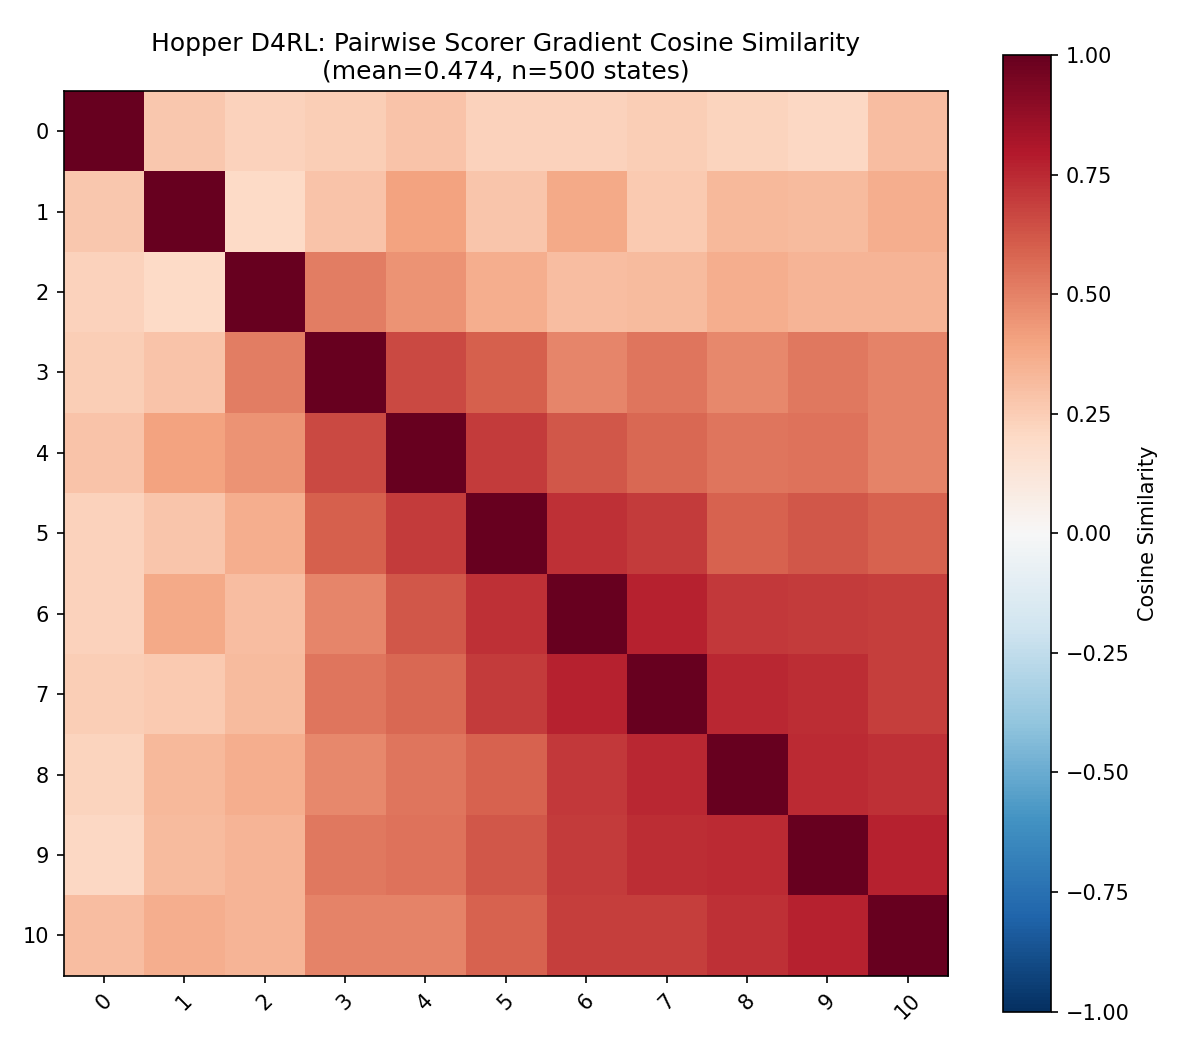

In [ ]:
n_samples = 500
idx = np.random.choice(len(obs), n_samples, replace=False)
states = torch.tensor(obs[idx], dtype=torch.float32, device=DEVICE)
acts = torch.tensor(actions[idx], dtype=torch.float32, device=DEVICE)

all_grads = []
for pi, policy in enumerate(target_policies):
    grads = []
    batch_size = 100
    for b in range(0, n_samples, batch_size):
        s_batch = states[b:b+batch_size].clone().detach()
        a_batch = acts[b:b+batch_size].clone().detach().requires_grad_(True)
        log_p = policy.log_prob(s_batch, a_batch)
        g = torch.autograd.grad(log_p.sum(), a_batch)[0]
        grads.append(g.detach())
    all_grads.append(torch.cat(grads, dim=0))
    print(f"  Policy {os.path.basename(policy_paths[pi])}: grad mean norm = {all_grads[-1].norm(dim=-1).mean():.4f}")

# Pairwise cosine similarity
n_policies = len(target_policies)
cosine_matrix = np.zeros((n_policies, n_policies))
for i, j in combinations(range(n_policies), 2):
    cos = torch.nn.functional.cosine_similarity(all_grads[i], all_grads[j], dim=-1)
    mean_cos = cos.mean().item()
    cosine_matrix[i, j] = mean_cos
    cosine_matrix[j, i] = mean_cos
np.fill_diagonal(cosine_matrix, 1.0)

upper_tri = cosine_matrix[np.triu_indices(n_policies, k=1)]
print(f"\nPairwise cosine similarity:")
print(f"  Mean:   {np.mean(upper_tri):.4f}")
print(f"  Std:    {np.std(upper_tri):.4f}")
print(f"  Min:    {np.min(upper_tri):.4f}")
print(f"  Max:    {np.max(upper_tri):.4f}")
print(f"  Median: {np.median(upper_tri):.4f}")

# Heatmap
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cosine_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
labels = [os.path.basename(p).replace(".pkl", "") for p in policy_paths]
ax.set_xticks(range(n_policies))
ax.set_yticks(range(n_policies))
ax.set_xticklabels(labels, rotation=45)
ax.set_yticklabels(labels)
plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title(f"Hopper D4RL: Pairwise Scorer Gradient Cosine Similarity\n(mean={np.mean(upper_tri):.3f}, n={n_samples} states)")
plt.tight_layout()
plt.show()

## Diagnostic 2: |grad| / |action| Ratio

Raw gradient magnitude relative to action magnitude. Our v0.2.5.3 found 12.86x.

  Policy 0: |grad|/|action| = 93.3 +/- 629.6  (|grad| mean=115.9, |action| mean=1.0712)
  Policy 1: |grad|/|action| = 774.9 +/- 4000.9  (|grad| mean=950.6, |action| mean=1.0712)
  Policy 2: |grad|/|action| = 445.9 +/- 2602.4  (|grad| mean=571.3, |action| mean=1.0712)
  Policy 3: |grad|/|action| = 359.5 +/- 1835.0  (|grad| mean=466.9, |action| mean=1.0712)
  Policy 4: |grad|/|action| = 376.8 +/- 2360.7  (|grad| mean=473.6, |action| mean=1.0712)
  Policy 5: |grad|/|action| = 627.8 +/- 3708.3  (|grad| mean=813.1, |action| mean=1.0712)
  Policy 6: |grad|/|action| = 805.7 +/- 4966.9  (|grad| mean=1036.1, |action| mean=1.0712)
  Policy 7: |grad|/|action| = 456.8 +/- 2819.7  (|grad| mean=591.2, |action| mean=1.0712)
  Policy 8: |grad|/|action| = 665.4 +/- 4815.0  (|grad| mean=866.7, |action| mean=1.0712)
  Policy 9: |grad|/|action| = 764.6 +/- 4744.6  (|grad| mean=995.0, |action| mean=1.0712)
  Policy 10: |grad|/|action| = 929.3 +/- 6687.7  (|grad| mean=1194.4, |action| mean=1.0712)


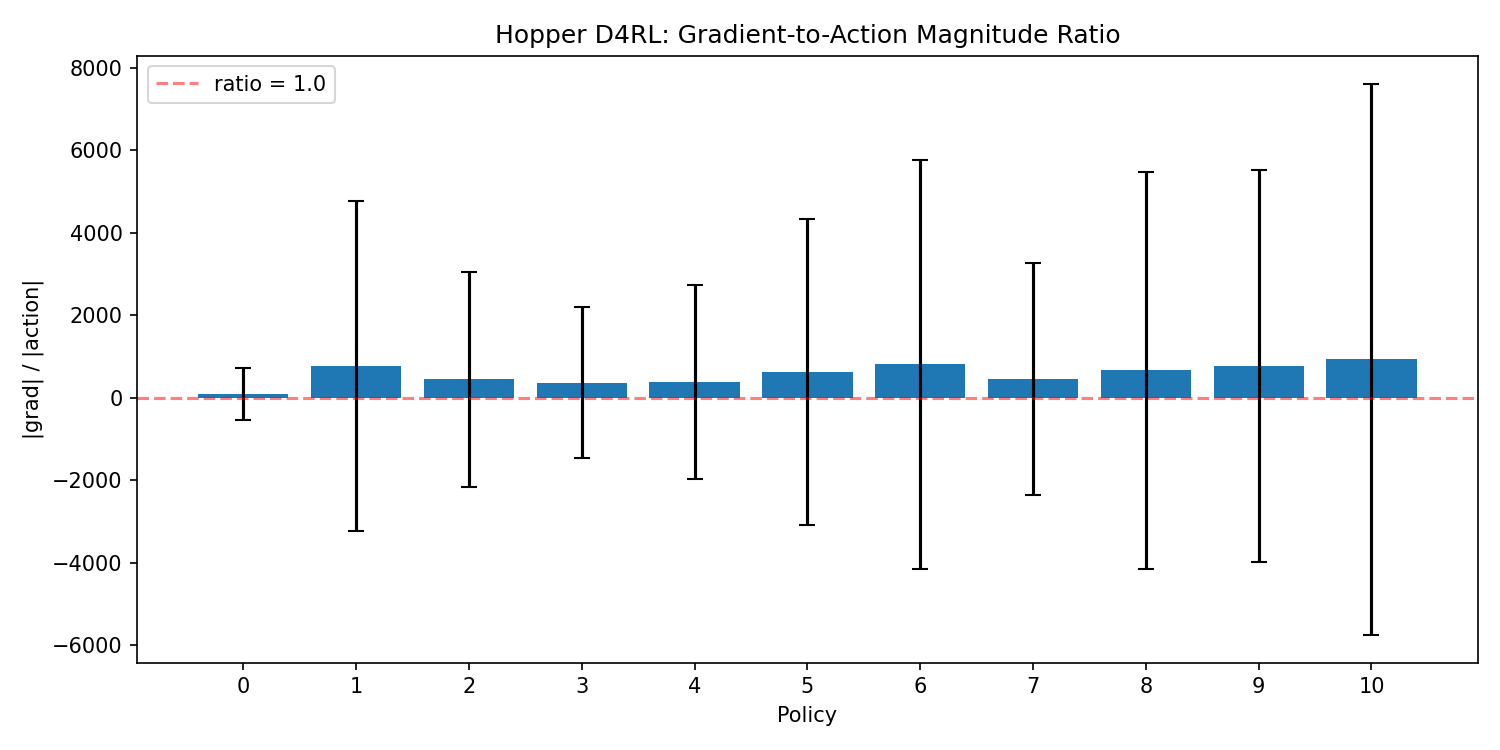

In [ ]:
idx2 = np.random.choice(len(obs), 500, replace=False)
states2 = torch.tensor(obs[idx2], dtype=torch.float32, device=DEVICE)
acts2 = torch.tensor(actions[idx2], dtype=torch.float32, device=DEVICE)
action_norms = acts2.norm(dim=-1)

ratio_results = []
for pi, policy in enumerate(target_policies):
    grads = []
    for b in range(0, 500, 100):
        s_batch = states2[b:b+100].clone().detach()
        a_batch = acts2[b:b+100].clone().detach().requires_grad_(True)
        log_p = policy.log_prob(s_batch, a_batch)
        g = torch.autograd.grad(log_p.sum(), a_batch)[0]
        grads.append(g.detach())
    grads = torch.cat(grads, dim=0)
    grad_norms = grads.norm(dim=-1)
    ratio = grad_norms / (action_norms + 1e-8)
    name = os.path.basename(policy_paths[pi]).replace(".pkl", "")
    print(f"  Policy {name}: |grad|/|action| = {ratio.mean():.1f} +/- {ratio.std():.1f}  "
          f"(|grad| mean={grad_norms.mean():.1f}, |action| mean={action_norms.mean():.4f})")
    ratio_results.append({"name": name, "ratio_mean": ratio.mean().item(), "ratio_std": ratio.std().item()})

fig, ax = plt.subplots(figsize=(10, 5))
names = [r["name"] for r in ratio_results]
means = [r["ratio_mean"] for r in ratio_results]
stds = [r["ratio_std"] for r in ratio_results]
ax.bar(names, means, yerr=stds, capsize=4)
ax.set_ylabel("|grad| / |action|")
ax.set_xlabel("Policy")
ax.set_title("Hopper D4RL: Gradient-to-Action Magnitude Ratio")
ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.5, label="ratio = 1.0")
ax.legend()
plt.tight_layout()
plt.show()

## Diagnostic 3: Gradient Direction Test

Can gradient ascent on `log_prob(s, a)` converge from random action toward real action? Our v0.2.5.4 showed +72% convergence.

In [ ]:
n_samples_gd, lr, n_steps = 200, 0.1, 50
idx3 = np.random.choice(len(obs), n_samples_gd, replace=False)
states3 = torch.tensor(obs[idx3], dtype=torch.float32, device=DEVICE)
real_actions3 = torch.tensor(actions[idx3], dtype=torch.float32, device=DEVICE)

gd_results = []
for pi, policy in enumerate(target_policies):
    a_opt = torch.randn(n_samples_gd, HOPPER_ACTION_DIM, device=DEVICE) * 0.5
    a_opt = a_opt.clone().detach().requires_grad_(True)
    initial_dist = (a_opt.detach() - real_actions3).norm(dim=-1).mean().item()

    for step in range(n_steps):
        if a_opt.grad is not None:
            a_opt.grad.zero_()
        log_p = policy.log_prob(states3, a_opt)
        log_p.sum().backward()
        with torch.no_grad():
            a_opt += lr * a_opt.grad
            a_opt.clamp_(-1, 1)
        a_opt = a_opt.clone().detach().requires_grad_(True)

    final_dist = (a_opt.detach() - real_actions3).norm(dim=-1).mean().item()
    improvement = (initial_dist - final_dist) / initial_dist * 100
    name = os.path.basename(policy_paths[pi]).replace(".pkl", "")
    print(f"  Policy {name}: init={initial_dist:.4f} -> final={final_dist:.4f}  improvement={improvement:.1f}%")
    gd_results.append({"name": name, "improvement_pct": improvement})

fig, ax = plt.subplots(figsize=(10, 5))
names = [r["name"] for r in gd_results]
improvements = [r["improvement_pct"] for r in gd_results]
colors = ["green" if imp > 0 else "red" for imp in improvements]
ax.bar(names, improvements, color=colors)
ax.set_ylabel("Improvement (%)")
ax.set_xlabel("Policy")
ax.set_title(f"Hopper D4RL: GD Convergence Test (lr={lr}, {n_steps} steps, {n_samples_gd} samples)")
ax.axhline(y=0, color="black", linestyle="-", alpha=0.3)
plt.tight_layout()
plt.show()

## Diagnostic 4: Per-Dimension Trajectory MSE (Unguided)

Generate 20 unguided trajectories via autoregressive chunk stitching and compare to real D4RL trajectories.

In [ ]:
# Load diffusion model
model_path = os.path.join(SOPE_ROOT, "opelab/examples/d4rl/models/hopper.pth")
T_chunk, D = 8, 256
transition_dim = HOPPER_STATE_DIM + HOPPER_ACTION_DIM

temporal_model = TemporalUnet(
    horizon=T_chunk, transition_dim=transition_dim, dim_mults=(1, 2, 4, 8), attention=False,
)
diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=T_chunk,
    observation_dim=HOPPER_STATE_DIM, action_dim=HOPPER_ACTION_DIM,
    n_timesteps=D, predict_epsilon=True,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
)
ckpt = torch.load(model_path, map_location=DEVICE)
diffusion_model.load_state_dict(ckpt)
diffusion_model.to(DEVICE)
diffusion_model.eval()
print(f"Loaded diffusion model: T={T_chunk}, D={D}, dim={transition_dim}")

Loaded diffusion model: T=8, D=256, dim=14


Generating 20 unguided trajectories (T_gen=200)...
Generated. Mean trajectory length: 200

Total state MSE: 3.723879
Per-dimension RMSE:
  z_pos          : 0.372174
  angle          : 0.047674
  thigh_angle    : 0.207174
  leg_angle      : 0.044340
  foot_angle     : 0.593149
  z_vel          : 0.608118
  angle_vel      : 1.319416
  thigh_vel      : 0.751520
  leg_vel        : 1.513185
  foot_vel       : 1.075886
  x_vel          : 5.856831


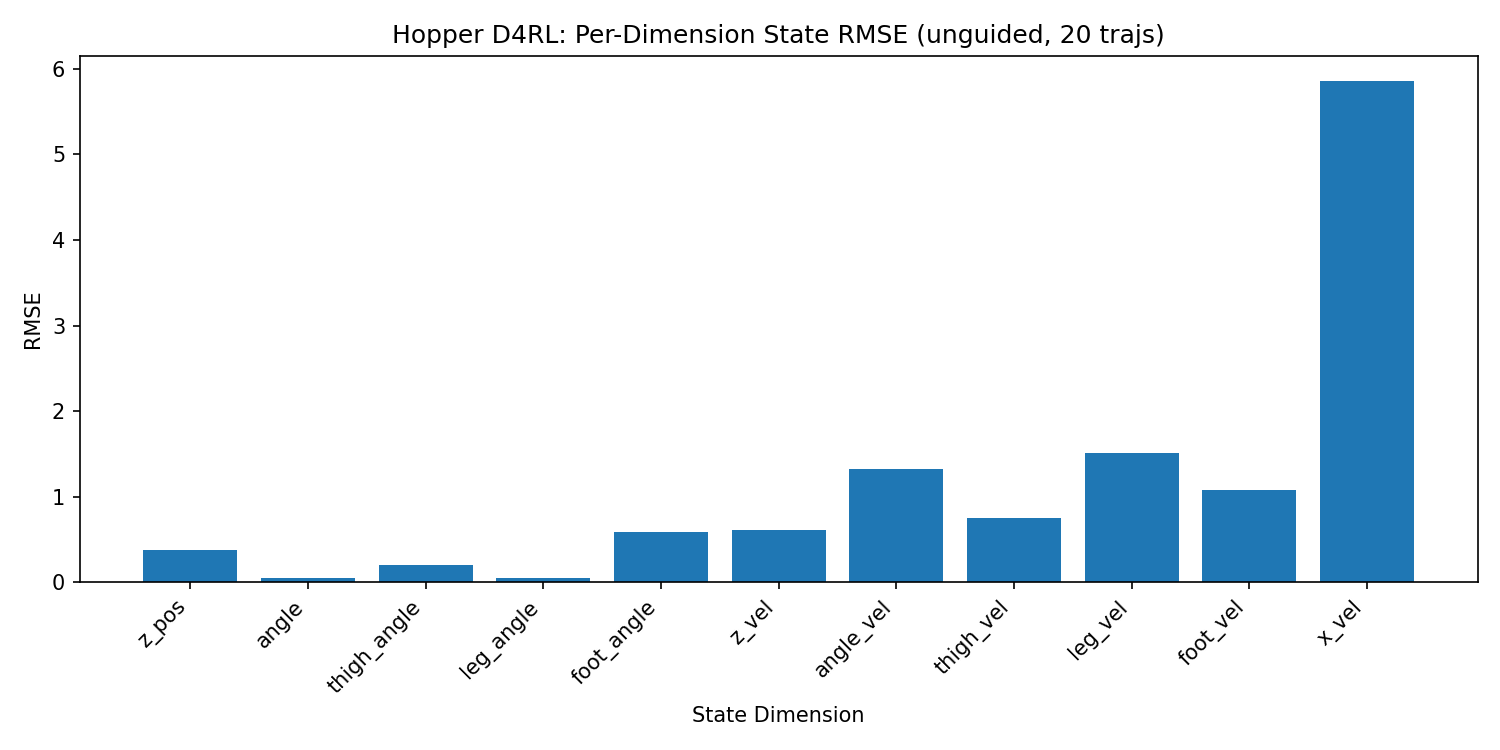

In [ ]:
def generate_trajectories_stitching(diffusion_model, normalize_fn, unnormalize_fn,
                                     initial_states, T_chunk, T_gen=200, batch_size=10,
                                     guided=False, guidance_hyperparams=None):
    """Generate full trajectories via autoregressive chunk stitching."""
    state_dim, action_dim = HOPPER_STATE_DIM, HOPPER_ACTION_DIM

    all_trajectories = torch.zeros(batch_size, T_gen, state_dim + action_dim, device=DEVICE)
    end_indices = torch.full((batch_size,), T_gen, dtype=torch.long, device=DEVICE)
    alive = torch.ones(batch_size, dtype=torch.bool, device=DEVICE)

    # Normalize initial states
    full_init = torch.zeros(batch_size, state_dim + action_dim, device=DEVICE)
    full_init[:, :state_dim] = initial_states[:batch_size]
    full_init_norm = normalize_fn(full_init)
    cond_states = full_init_norm[:, :state_dim]

    t_written = 0
    for chunk_idx in range(T_gen // T_chunk + 2):
        if not alive.any() or t_written >= T_gen:
            break

        cond = {0: cond_states[alive]}
        alive_count = alive.sum().item()

        if guided and guidance_hyperparams is not None:
            samples = diffusion_model.conditional_sample(
                shape=(alive_count, T_chunk, state_dim + action_dim),
                cond=cond, guided=True, **guidance_hyperparams)
        else:
            samples = diffusion_model.conditional_sample(
                shape=(alive_count, T_chunk, state_dim + action_dim),
                cond=cond, guided=False)

        chunk_unnorm = unnormalize_fn(samples.trajectories)
        start = 0 if chunk_idx == 0 else 1

        for local_t in range(start, T_chunk):
            if t_written >= T_gen:
                break
            alive_indices = torch.where(alive)[0]
            all_trajectories[alive_indices, t_written] = chunk_unnorm[:, local_t]

            for bi, idx_val in enumerate(alive_indices):
                state = all_trajectories[idx_val, t_written, :state_dim]
                s_np = state.cpu().numpy()
                terminated = not (
                    np.isfinite(s_np).all() and (np.abs(s_np[2:]) < 100).all()
                    and s_np[0] > 0.7 and abs(s_np[1]) < 0.2)
                if terminated:
                    alive[idx_val] = False
                    end_indices[idx_val] = t_written
            t_written += 1

        if alive.any():
            last_frame = samples.trajectories[:, -1, :]
            new_cond = []
            ai = 0
            for i in range(batch_size):
                if alive[i]:
                    new_cond.append(last_frame[ai, :state_dim])
                    ai += 1
            if new_cond:
                cond_states_new = torch.zeros(batch_size, state_dim, device=DEVICE)
                ai = 0
                for i in range(batch_size):
                    if alive[i]:
                        cond_states_new[i] = new_cond[ai]
                        ai += 1
                cond_states = cond_states_new

    return all_trajectories, end_indices

# Generate trajectories
n_trajs, T_gen = 20, 200
initial_states = torch.tensor(
    np.array([t["observations"][0] for t in trajs[:n_trajs]]),
    dtype=torch.float32, device=DEVICE)

print(f"Generating {n_trajs} unguided trajectories (T_gen={T_gen})...")
synth_trajs, end_indices = generate_trajectories_stitching(
    diffusion_model, normalize_fn, unnormalize_fn,
    initial_states, T_chunk, T_gen=T_gen, batch_size=n_trajs, guided=False)
print(f"Generated. Mean trajectory length: {end_indices.float().mean():.0f}")

# Per-dimension MSE
state_mses = []
for i in range(n_trajs):
    real_len = min(trajs[i]["length"], T_gen, end_indices[i].item())
    if real_len < 5:
        continue
    real_states = torch.tensor(trajs[i]["observations"][:real_len], dtype=torch.float32)
    synth_states = synth_trajs[i, :real_len, :HOPPER_STATE_DIM].cpu()
    mse = (real_states - synth_states).pow(2).mean(dim=0)
    state_mses.append(mse)

per_dim_mse = torch.stack(state_mses).mean(dim=0).numpy()
per_dim_rmse = np.sqrt(per_dim_mse)

print(f"\nTotal state MSE: {per_dim_mse.mean():.6f}")
print(f"Per-dimension RMSE:")
for d, name in enumerate(HOPPER_STATE_NAMES):
    print(f"  {name:15s}: {per_dim_rmse[d]:.6f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(HOPPER_STATE_NAMES, per_dim_rmse)
ax.set_ylabel("RMSE")
ax.set_xlabel("State Dimension")
ax.set_title(f"Hopper D4RL: Per-Dimension State RMSE (unguided, {len(state_mses)} trajs)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Diagnostic 5: Action NLL Under Target Policies

NLL of unguided synthetic trajectory actions under each target policy.

  Policy 0: mean NLL = 3.9376 +/- 0.3912
  Policy 1: mean NLL = 39.2697 +/- 3.5554
  Policy 2: mean NLL = 43.8374 +/- 13.7763
  Policy 3: mean NLL = 37.3519 +/- 4.7107
  Policy 4: mean NLL = 33.2495 +/- 3.4501
  Policy 5: mean NLL = 36.2431 +/- 6.8400
  Policy 6: mean NLL = 41.3247 +/- 11.0184
  Policy 7: mean NLL = 28.8938 +/- 4.5875
  Policy 8: mean NLL = 32.1319 +/- 5.8465
  Policy 9: mean NLL = 29.4273 +/- 3.4126
  Policy 10: mean NLL = 34.4320 +/- 4.0758


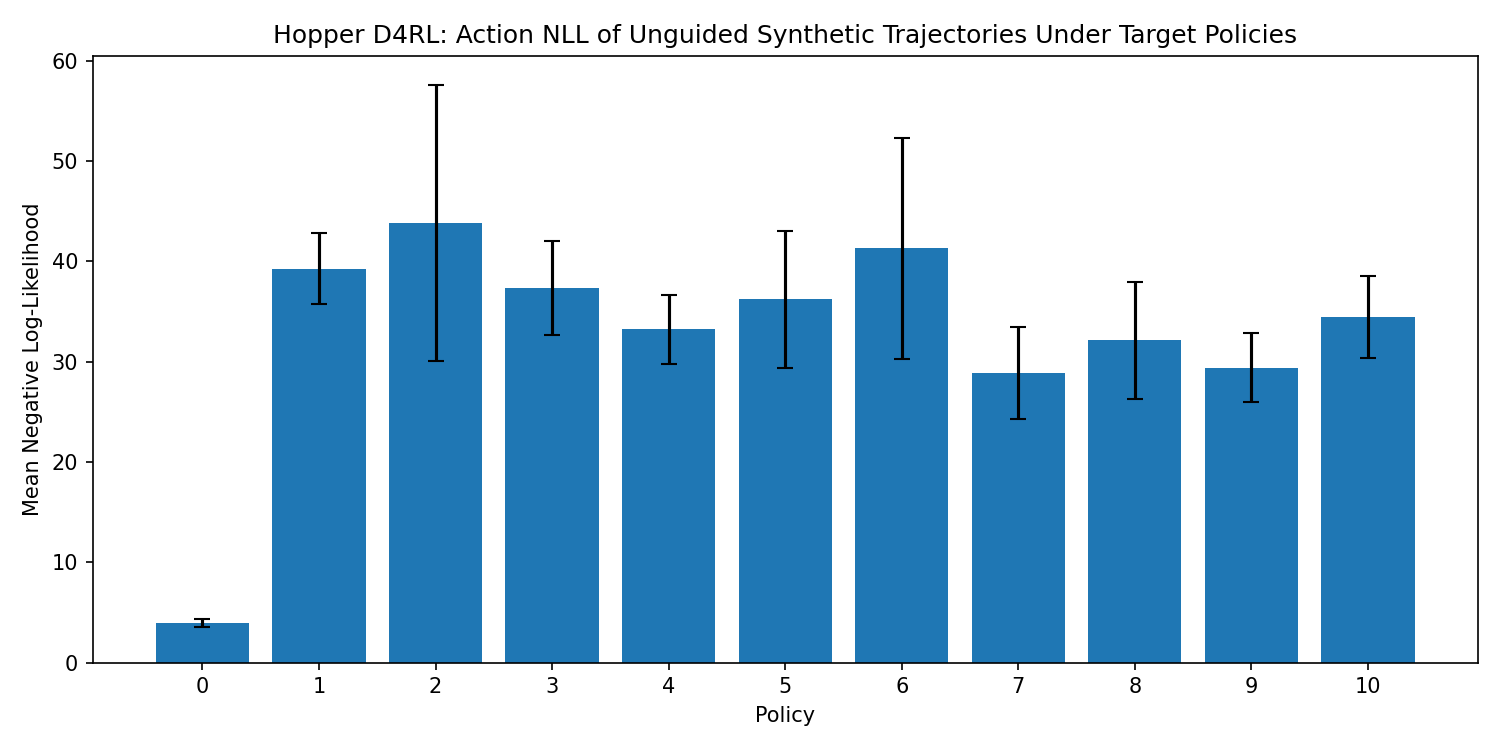

In [ ]:
nll_results = []
for pi, policy in enumerate(target_policies):
    nlls = []
    for i in range(n_trajs):
        T = min(end_indices[i].item(), synth_trajs.shape[1])
        if T < 2:
            continue
        s = synth_trajs[i, :T, :HOPPER_STATE_DIM].detach()
        a = synth_trajs[i, :T, HOPPER_STATE_DIM:].detach()
        with torch.no_grad():
            log_p = policy.log_prob(s, a)
        nlls.append(-log_p.mean().item())
    name = os.path.basename(policy_paths[pi]).replace(".pkl", "")
    print(f"  Policy {name}: mean NLL = {np.mean(nlls):.4f} +/- {np.std(nlls):.4f}")
    nll_results.append({"name": name, "nll_mean": np.mean(nlls), "nll_std": np.std(nlls)})

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([r["name"] for r in nll_results],
       [r["nll_mean"] for r in nll_results],
       yerr=[r["nll_std"] for r in nll_results], capsize=4)
ax.set_ylabel("Mean Negative Log-Likelihood")
ax.set_xlabel("Policy")
ax.set_title("Hopper D4RL: Action NLL of Unguided Synthetic Trajectories Under Target Policies")
plt.tight_layout()
plt.show()

## Diagnostic 6: Trajectory Plots — Real vs Synthetic

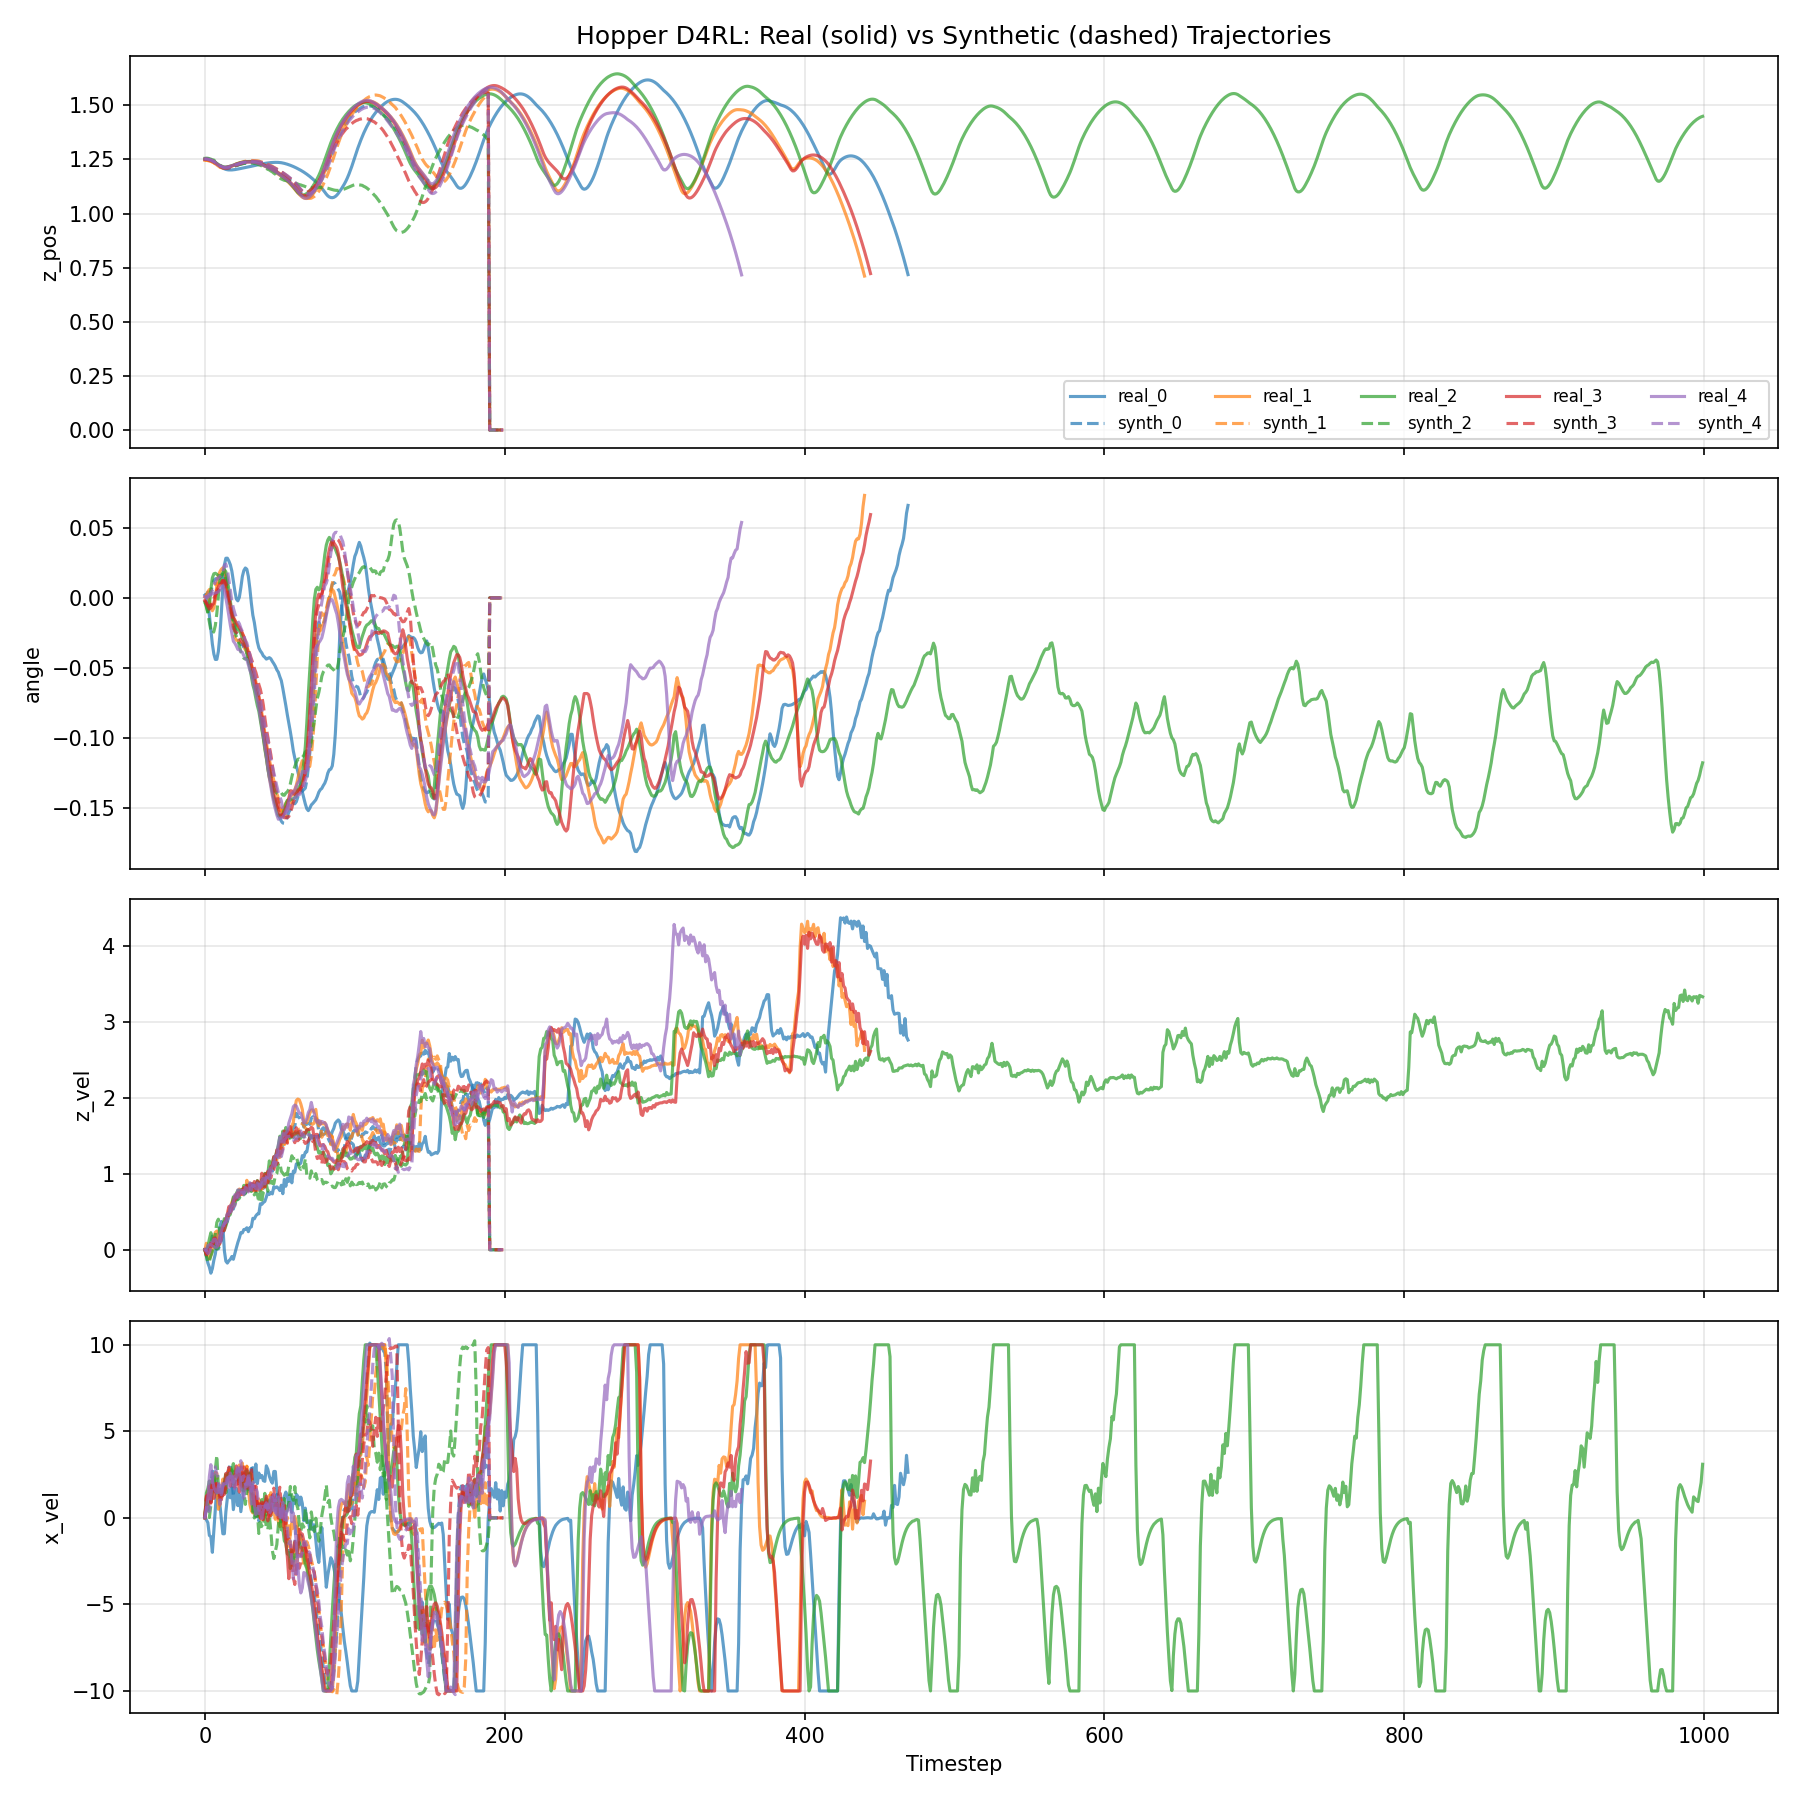

In [ ]:
key_dims = [0, 1, 5, 10]
key_names = ["z_pos", "angle", "z_vel", "x_vel"]
n_plot = 5

fig, axes = plt.subplots(len(key_dims), 1, figsize=(12, 3 * len(key_dims)), sharex=True)
for di, (dim, name) in enumerate(zip(key_dims, key_names)):
    ax = axes[di]
    for i in range(min(n_plot, len(trajs))):
        real_len = trajs[i]["length"]
        synth_len = min(end_indices[i].item(), synth_trajs.shape[1])
        ax.plot(trajs[i]["observations"][:real_len, dim],
                color=f"C{i}", alpha=0.7, linewidth=1.5,
                label=f"real_{i}" if di == 0 else None)
        ax.plot(synth_trajs[i, :synth_len, dim].cpu().numpy(),
                color=f"C{i}", alpha=0.7, linewidth=1.5, linestyle="--",
                label=f"synth_{i}" if di == 0 else None)
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)
axes[0].set_title("Hopper D4RL: Real (solid) vs Synthetic (dashed) Trajectories")
axes[0].legend(ncol=n_plot, fontsize=8)
axes[-1].set_xlabel("Timestep")
plt.tight_layout()
plt.show()

## Summary

Comparison of Hopper D4RL reference values vs our Lift v0.2.5.X results.

  Policy 0: |grad|/|action| = 93.3 +/- 629.6  (|grad| mean=115.9, |action| mean=1.0712)
  Policy 1: |grad|/|action| = 774.9 +/- 4000.9  (|grad| mean=950.6, |action| mean=1.0712)
  Policy 2: |grad|/|action| = 445.9 +/- 2602.4  (|grad| mean=571.3, |action| mean=1.0712)
  Policy 3: |grad|/|action| = 359.5 +/- 1835.0  (|grad| mean=466.9, |action| mean=1.0712)
  Policy 4: |grad|/|action| = 376.8 +/- 2360.7  (|grad| mean=473.6, |action| mean=1.0712)
  Policy 5: |grad|/|action| = 627.8 +/- 3708.3  (|grad| mean=813.1, |action| mean=1.0712)
  Policy 6: |grad|/|action| = 805.7 +/- 4966.9  (|grad| mean=1036.1, |action| mean=1.0712)
  Policy 7: |grad|/|action| = 456.8 +/- 2819.7  (|grad| mean=591.2, |action| mean=1.0712)
  Policy 8: |grad|/|action| = 665.4 +/- 4815.0  (|grad| mean=866.7, |action| mean=1.0712)
  Policy 9: |grad|/|action| = 764.6 +/- 4744.6  (|grad| mean=995.0, |action| mean=1.0712)
  Policy 10: |grad|/|action| = 929.3 +/- 6687.7  (|grad| mean=1194.4, |action| mean=1.0712)


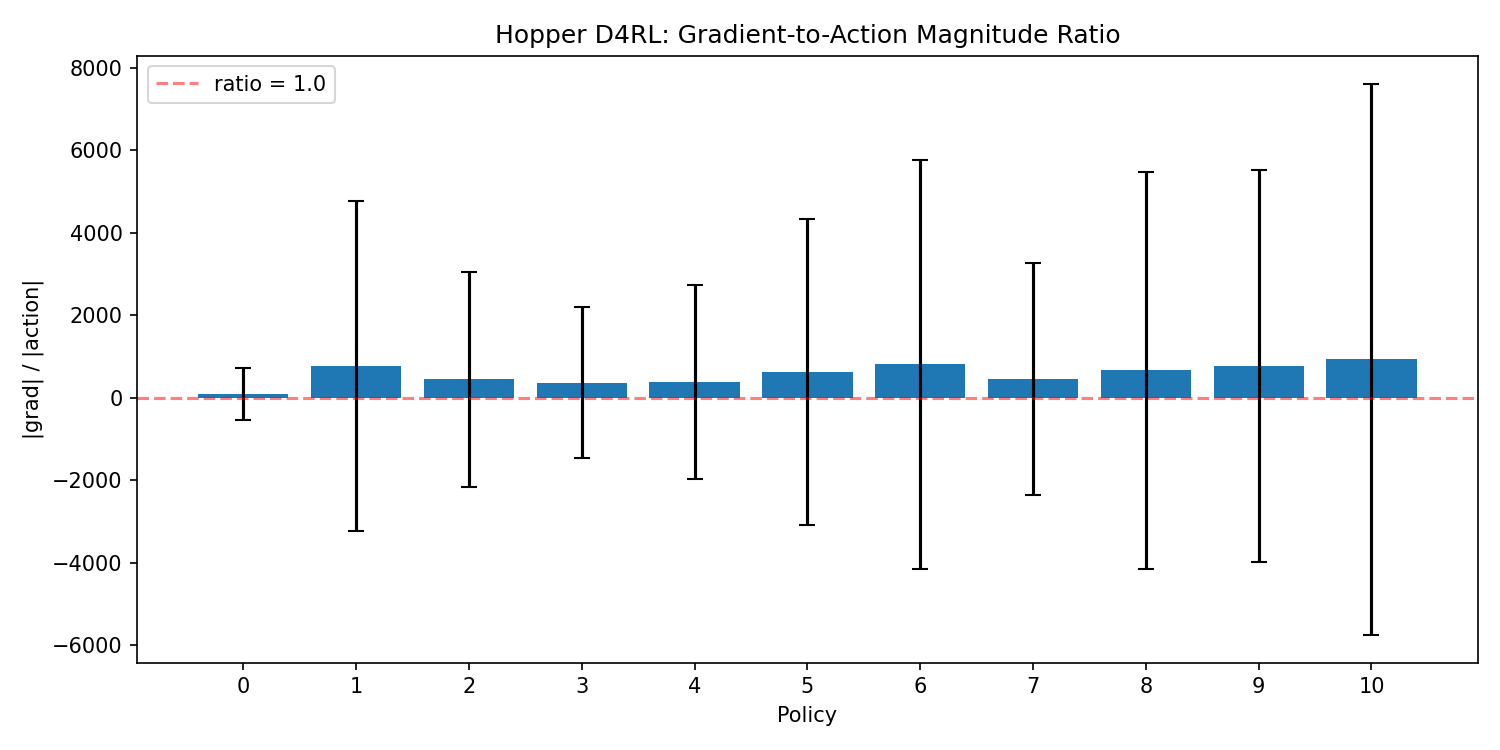

In [ ]:
upper_tri = cosine_matrix[np.triu_indices(n_policies, k=1)]
mean_ratio = np.mean([r["ratio_mean"] for r in ratio_results])
mean_improvement = np.mean([r["improvement_pct"] for r in gd_results])

print("=" * 70)
print("SUMMARY: Hopper D4RL (reference) vs Our Lift (v0.2.5.X)")
print("=" * 70)
print(f"{'Diagnostic':<40} {'Hopper D4RL':>15} {'Lift v0.2.5.X':>15}")
print("-" * 70)
print(f"{'Cosine sim (scorer grads)':<40} {np.mean(upper_tri):>15.4f} {'0.72-0.95':>15}")
print(f"{'|grad|/|action| ratio':<40} {mean_ratio:>15.1f} {'12.86':>15}")
print(f"{'GD convergence improvement':<40} {mean_improvement:>14.1f}% {'72%':>15}")
print(f"{'Total state RMSE (unguided)':<40} {np.sqrt(np.mean(per_dim_rmse**2)):>15.4f} {'N/A':>15}")
print(f"{'NLL spread (min-max)':<40} {min(r['nll_mean'] for r in nll_results):>5.1f} - {max(r['nll_mean'] for r in nll_results):>5.1f}   {'marginal':>15}")
print("=" * 70)
print()
print("Key takeaway: Hopper SAC policies produce much more distinguishable")
print("gradient directions (cosine 0.47) than our robomimic policies (0.72-0.95).")
print("This is the primary bottleneck for guidance-based multi-policy OPE on Lift.")